In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [8]:
fraud = df[df.Class == 0]
Non_fraud = df[df.Class == 1]

In [9]:
fraud['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
Non_fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

## EDA

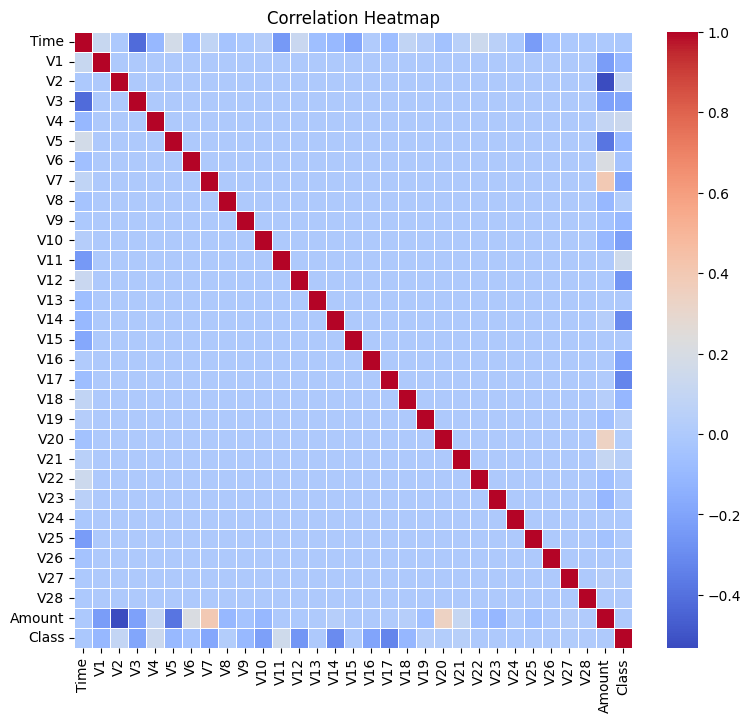

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

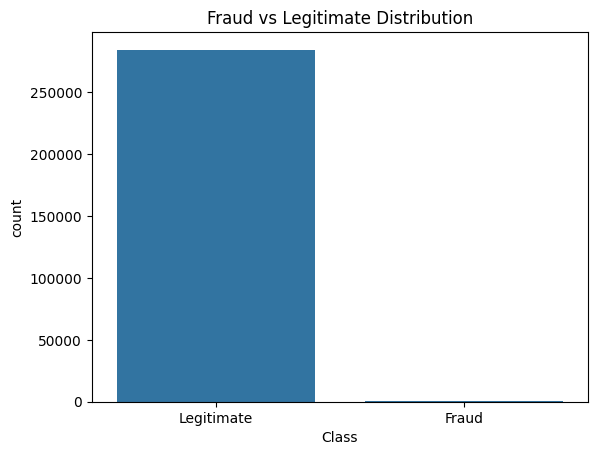

In [12]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Legitimate Distribution")
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

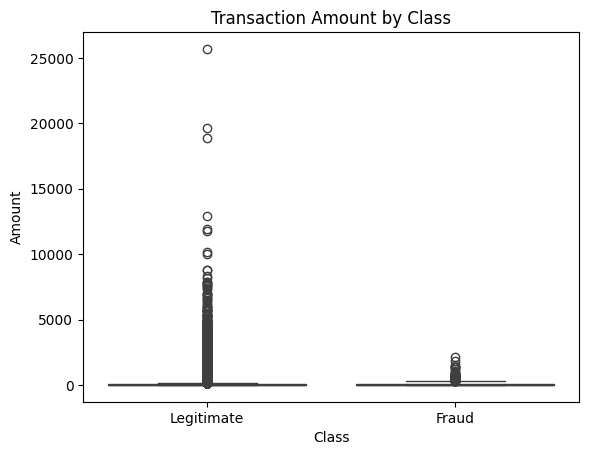

In [13]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

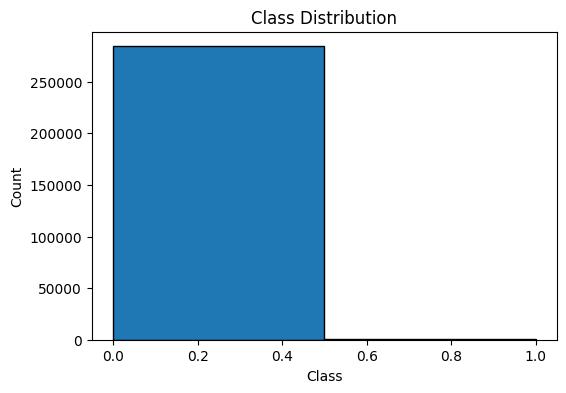

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Class'], bins=len(df['Class'].unique()), edgecolor='black')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Amount', ylabel='Count'>

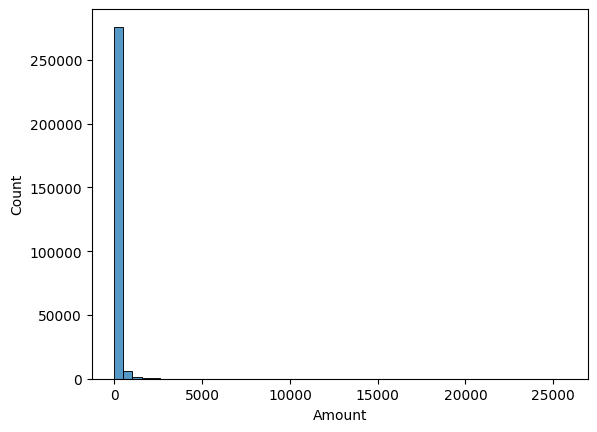

In [15]:
sns.histplot(df['Amount'], bins=50, kde=False)

## Train Test data 

In [16]:
X = df.drop(columns = 'Class', axis = 1)
y = df['Class']

## Standard Scaler

In [17]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_Scaler = sc.fit_transform(X)

In [18]:
(X_Scaler)

array([[-1.99658302, -0.69424232, -0.04407492, ...,  0.33089162,
        -0.06378115,  0.24496426],
       [-1.99658302,  0.60849633,  0.16117592, ..., -0.02225568,
         0.04460752, -0.34247454],
       [-1.99656197, -0.69350046, -0.81157783, ..., -0.13713686,
        -0.18102083,  1.16068593],
       ...,
       [ 1.6419735 ,  0.98002374, -0.18243372, ...,  0.01103672,
        -0.0804672 , -0.0818393 ],
       [ 1.6419735 , -0.12275539,  0.32125034, ...,  0.26960398,
         0.31668678, -0.31324853],
       [ 1.64205773, -0.27233093, -0.11489898, ..., -0.00598394,
         0.04134999,  0.51435531]])

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42, stratify = y)

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Train Accuracy

In [21]:
from sklearn.metrics import accuracy_score
X_train_pred = model.predict(X_train)
train_acc = accuracy_score(X_train_pred, y_train)
train_acc

0.999227546171672

## Test Accuracy

In [22]:
X_test_pred = model.predict(X_test)
test_acc = accuracy_score(X_test_pred, y_test)
test_acc

0.9992556388865481

In [23]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, X_train_pred))
print("Test Accuracy:", accuracy_score(y_test, X_test_pred))

print("\nClassification Report (Train):")
print(classification_report(y_train, X_train_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, X_test_pred))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, X_test_pred))

Training Accuracy: 0.999227546171672
Test Accuracy: 0.9992556388865481

Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    213236
           1       0.84      0.68      0.75       369

    accuracy                           1.00    213605
   macro avg       0.92      0.84      0.88    213605
weighted avg       1.00      1.00      1.00    213605


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.84      0.70      0.76       123

    accuracy                           1.00     71202
   macro avg       0.92      0.85      0.88     71202
weighted avg       1.00      1.00      1.00     71202


Confusion Matrix (Test):
[[71063    16]
 [   37    86]]


## Class Imbalancement using Smote technique, can use combination of over sampling and undersampling 

In [24]:
from imblearn.over_sampling import SMOTE
over_sample = SMOTE()
X_smote , y_smote = over_sample.fit_resample(X_train, y_train)

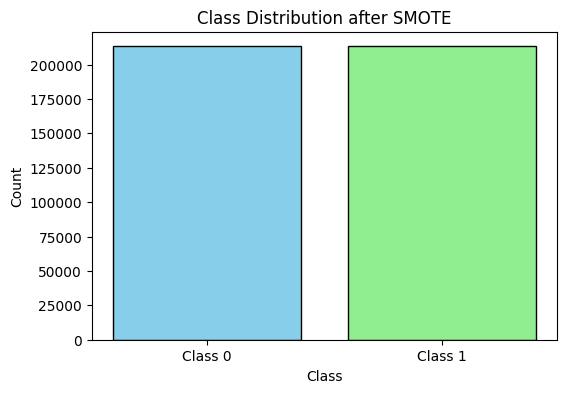

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Count occurrences of each class
classes, counts = np.unique(y_smote, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(classes, counts, color=['skyblue','lightgreen'], edgecolor='black')
plt.title("Class Distribution after SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes, ['Class 0','Class 1'])  # label x-axis as 0 and 1
plt.show()

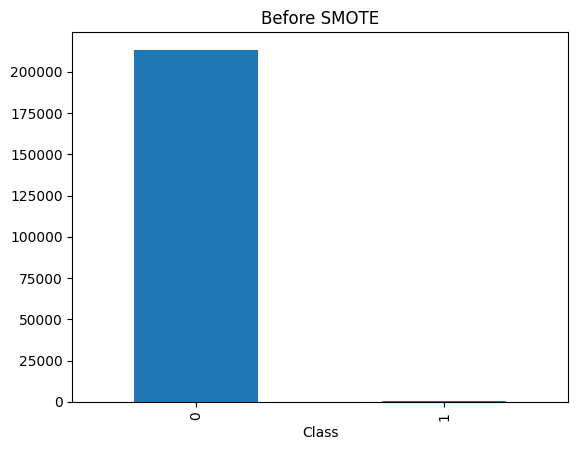

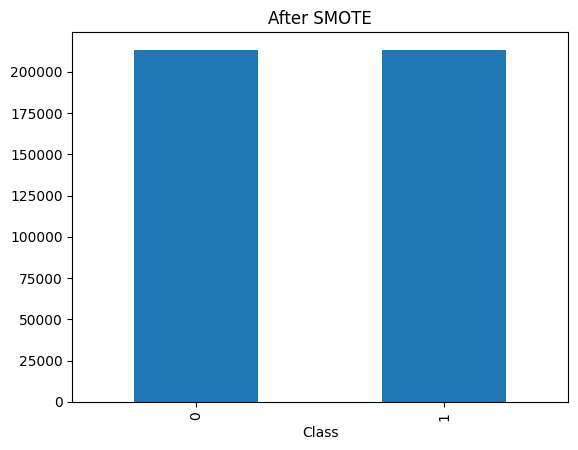

In [26]:
import matplotlib.pyplot as plt

# Before SMOTE
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

# After SMOTE
pd.Series(y_smote).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_smote, y_smote)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [28]:
best_f1_lr = 0
best_thresh_lr = 0

for t in np.linspace(0.01, 0.99, 100):
    y_pred_temp = (y_prob_lr > t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_thresh_lr = t

print("LR Best Threshold:", best_thresh_lr)
print("LR Best F1:", best_f1_lr)

LR Best Threshold: 0.99
LR Best F1: 0.7220216606498195


In [29]:
y_pred_lr = (y_prob_lr > best_thresh_lr).astype(int)

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.65      0.81      0.72       123

    accuracy                           1.00     71202
   macro avg       0.82      0.91      0.86     71202
weighted avg       1.00      1.00      1.00     71202

[[71025    54]
 [   23   100]]


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_smote, y_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [32]:
best_f1_xgb = 0
best_thresh_xgb = 0

for t in np.linspace(0.01, 0.99, 100):
    y_pred_temp = (y_prob_xgb > t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_thresh_xgb = t

print("\nXGB Best Threshold:", best_thresh_xgb)
print("XGB Best F1:", best_f1_xgb)


XGB Best Threshold: 0.99
XGB Best F1: 0.8672566371681416


In [33]:
y_pred_xgb = (y_prob_xgb > best_thresh_xgb).astype(int)

print("\nXGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.95      0.80      0.87       123

    accuracy                           1.00     71202
   macro avg       0.98      0.90      0.93     71202
weighted avg       1.00      1.00      1.00     71202

[[71074     5]
 [   25    98]]


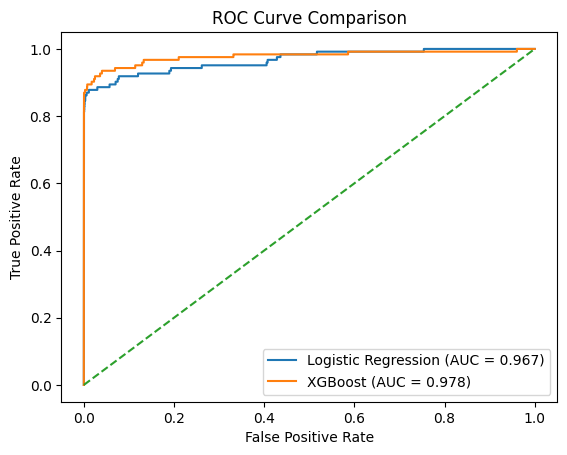

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Logistic Regression ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# --- XGBoost ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# --- Plot ---
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

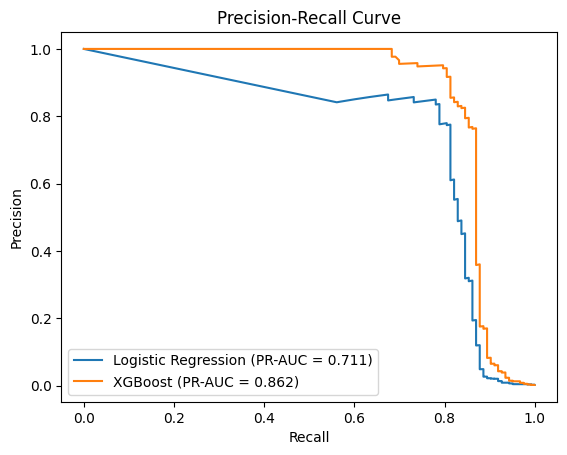

In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# --- Logistic Regression ---
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

# --- XGBoost ---
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

# --- Plot ---
plt.figure()

plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (PR-AUC = {pr_auc_lr:.3f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (PR-AUC = {pr_auc_xgb:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

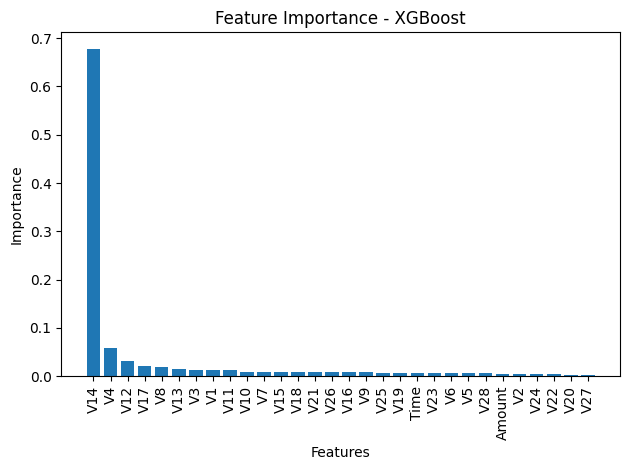

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from trained model
importances = xgb_model.feature_importances_

# Feature names
features = X.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort values
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.bar(feat_imp['Feature'], feat_imp['Importance'])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()